
### MeSH mapping and hierarchical processing

This section of the pipeline maps **UMLS CUIs** to their corresponding **MeSH UIDs** and retrieves **hierarchical relationships** from the MeSH ontology to support score normalisation across related diseases.

The process begins by adding two new columns to the `ranked_df`:
- `"MSH"`: stores the mapped **MeSH UID**.
- `"MSH_normalised_name"`: contains the corresponding standardised **MeSH disease name**.

For each disease (row) in `ranked_df`, the CUI is used to fetch:
- A MeSH UID via `fetch_mesh_from_cui(cui)`.
- A normalised name via `fetch_mesh_name(mesh_id)`.

These mappings ensure consistency in disease terminology and allow downstream use of the structured MeSH hierarchy.

Diseases without valid MeSH mappings are removed to maintain data integrity. The full mapping of CUI to MeSH IDs and disease names is then saved to `hierarchies/MeSH_mapping.csv`.

For the **top 10 ranked genes**, the script creates individual input files located in `hierarchies/input_files/`. Each file contains:
- The **MeSH-normalised disease name**.
- The **MeSH UID**.
- The **GDA score** (`score`) from DisGeNET.

To avoid redundancy, only the highest-scoring entry is kept per MeSH term. This ensures that each disease is represented uniquely and meaningfully for the gene.

Each input file is then processed to:
- **Fetch MeSH parent terms** for each disease via the UMLS API (`/parents` endpoint).
- **Construct tree-like structures**, where diseases are connected to their ancestors in the MeSH ontology.
- **Filter out diseases that are themselves parents**, focusing the analysis on leaf or intermediate terms.

The script recursively builds **hierarchical trees** for each non-parent disease using the `build_tree` function, storing:
- The disease’s level in the hierarchy.
- The original GDA score.
- All ancestral relationships.

These trees are then merged to represent the full hierarchical context of each disease-gene association.

Finally, for each gene, a `.txt` file is saved in `hierarchies/output_files/` that contains:
- A visual, indented tree of diseases and their parents.
- Scores annotated at each level.
- An **average GDA score** computed over all nodes in the tree, offering a smoothed, hierarchy-aware representation of disease burden per gene.

![MAPT Alzheimer Hierarchy](../hierarchies/hierarchy_example.png)

##### Why use MeSH hierarchy-based aggregation in drug repositioning?

The MeSH hierarchy groups diseases into structured, parent–child relationships. In drug repositioning:
- A drug might not target a disease directly, but its parent condition (e.g. Alzheimer disease → Dementia).
- Aggregating scores along the MeSH tree allows one to:
    - Smooth noisy associations.
    - Capture indirect links between genes and broader disease categories.
    - Identify targetable diseases within the same pathological cluster.

This is especially useful in polypharmacology, where one drug may act on multiple targets involved in related conditions.

In [1]:
import sys
sys.path.append("../src")

import utils.skip_magic

import requests
import time
import glob
import os
import re
import cache
import json
import gzip
import shutil
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import ast
import pandas as pd
import seaborn as sns
import numpy as np
from math import pi
from adjustText import adjust_text
from tqdm import tqdm
from collections import defaultdict
from io import StringIO
from urllib.request import urlopen

file_path = "../data/DISEASES_Summary_GDA_CURATED_C0030567.tsv"  # Change for your desired file
API_KEY = "7eaf32db-24f3-4d66-b3cc-cc9a1ad56f9a"  # Replace with your actual UMLS API key
API_DELAY = 0.8
CUI = "C0030567"  # Change with CUI corresponding to your .tsv file from DisGeNET
BASE_URL = "https://uts-ws.nlm.nih.gov/rest/content/current/"
cui_mesh_mapping = pd.read_csv("../data/CUI_to_MeSH.csv", dtype=str).set_index("CUI")["MSH"].to_dict()

def fetch_mesh_from_cui(cui):
    """Fetches the MeSH ID from the precomputed mapping file or UMLS API."""
    # Checks if CUI exists in precomputed mappings
    if cui in cui_mesh_mapping:
        return cui_mesh_mapping[cui]
    # If not found, queries UMLS API
    cui_url = f"{BASE_URL}CUI/{cui}/atoms?apiKey={API_KEY}"
    response = requests.get(cui_url)
    if response.status_code == 200:
        data = response.json()
        for result in data.get("result", []):
            if result["rootSource"].startswith("MSH") and "sourceDescriptor" in result:
                mesh_id = result["sourceDescriptor"].split("/")[-1]
                # Updates the dictionary with the new mapping to avoid repeated API calls
                cui_mesh_mapping[cui] = mesh_id
                return mesh_id
    print(f"MeSH ID not found for CUI: {cui}")
    return None

def fetch_mesh_name(mesh_id, name_dict=None):
    """Fetches the normalised MeSH disease name from the UMLS API."""
    # Exclude only known non-MeSH formats, but keep valid 'C' prefix MeSH IDs
    if not mesh_id or mesh_id.startswith("U") or mesh_id.startswith("V-MSH"):
        return None
    # Use name_dict if provided, otherwise skip dictionary check
    if name_dict and mesh_id in name_dict:
        return name_dict[mesh_id]
    try:
        time.sleep(API_DELAY)
        url = f"{BASE_URL}source/MSH/{mesh_id}?apiKey={API_KEY}"
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if "result" in data and "name" in data["result"]:
                return data["result"]["name"]
    except Exception as e:
        print(f"Error fetching MeSH name for {mesh_id}: {e}")
    return None

selected_mesh_id = fetch_mesh_from_cui(CUI)
selected_mesh_name = fetch_mesh_name(selected_mesh_id)

if selected_mesh_id and selected_mesh_name:
    print(f"MeSH ID for {selected_mesh_name} is {selected_mesh_id}.")
else:
    print("Failed to fetch MeSH ID or name.")

MeSH ID for Parkinson Disease is D010300.


In [2]:
merged_df = pd.read_csv("../data/targetability_score.csv")

# Define API parameters
base_url = "https://api.disgenet.com/api/v1/gda/summary"
headers = {
    "accept": "application/csv",
    "Authorization": "59699c2e-c741-4eb2-b31b-57d446a785f9"
}
order_by = "score"
max_pages = 6  # DisGeNET API allows a maximum of 100 pages, so adjust accordingly

top_genes = merged_df.sort_values(by="TS", ascending=False)["Gene"].head(10).tolist()  # Get the top genes from `merged_df`
genes = ",".join(top_genes)
df_list = []
for page in range(max_pages):
    print(f"Fetching page {page + 1}/{max_pages}")
    url = f"{base_url}?gene_symbol={genes}&order_by={order_by}&page_number={page}"  # Construct request URL with pagination
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        response_text = response.text
        try:
            df_page = pd.read_csv(StringIO(response_text), sep=",")
        except pd.errors.ParserError:
            print(f"CSV failed on page {page}, trying tab-separated format...")
            df_page = pd.read_csv(StringIO(response_text), sep="\t")
        df_list.append(df_page)
    else:
        print(f"Failed to fetch page {page}. Status code: {response.status_code}")
        break

# Merge all retrieved pages
ranked_df = pd.concat(df_list, ignore_index=True)
if ranked_df.columns[-1].startswith("EI"):
   ranked_df = ranked_df.iloc[:, :-1]  # Drop the last column if malformed

# Drop unnecessary columns
columns_to_drop = [
    "EI", "EL", "assocID", "chemsIncludedInEvidenceBySource", "diseaseClasses_DO", "diseaseClasses_HPO", "diseaseClasses_UMLS_ST", "diseaseVocabularies", "geneDPI",
    "geneDSI", "geneEnsemblIDs", "geneProteinClassIDs", "geneProteinStrIDs", "genepLI", "numCTsupportingAssociation", "numChemsIncludedInEvidences", 
    "numPMIDSWithChemsIncludedInEvidences", "numPMIDs", "numberChemsFiltered", "numberPmidsWithChemsFiltered", "yearFinal", "yearInitial"
]
ranked_df = ranked_df.drop(columns=columns_to_drop, errors='ignore')

if "symbolOfGene" in ranked_df.columns and "score" in ranked_df.columns:
    top_genes_order = {gene: rank for rank, gene in enumerate(top_genes) if gene in ranked_df["symbolOfGene"].unique()}
    # Assign gene rank based on the predefined order
    ranked_df["gene_rank"] = ranked_df["symbolOfGene"].map(top_genes_order)
    # Sort by gene rank (preserving the predetermined order) and then by score (descending)
    ranked_df = ranked_df.sort_values(by=["gene_rank", "score"], ascending=[True, False]).drop(columns=["gene_rank"])

ranked_df.to_csv("../data/DisGDis.csv", index=False)
ranked_df

Fetching page 1/6
CSV failed on page 0, trying tab-separated format...
Fetching page 2/6
CSV failed on page 1, trying tab-separated format...
Fetching page 3/6
CSV failed on page 2, trying tab-separated format...
Fetching page 4/6
CSV failed on page 3, trying tab-separated format...
Fetching page 5/6
Fetching page 6/6


,diseaseClasses_MSH,diseaseName,diseaseType,diseaseUMLSCUI,disease_inheritance,disease_prevalence_class,disease_prevalence_geo_area,disease_prevalence_type,geneNcbiID,geneNcbiType,geneProteinClassNames,score,symbolOfGene
14,[Nervous System Diseases (C10)],Parkinson Disease,disease,C0030567,NaN,NaN,NaN,NaN,4129.0,protein-coding,[],1.00,MAOB
32,"[Mental Disorders (F03), Nervous System Diseas...",Alzheimer's Disease,disease,C0002395,NaN,NaN,NaN,NaN,4129.0,protein-coding,[],0.95,MAOB
63,[Mental Disorders (F03)],Depressive disorder,disease,C0011581,NaN,NaN,NaN,NaN,4129.0,protein-coding,[],0.85,MAOB
65,[Behavior and Behavior Mechanisms (F01)],Mental Depression,disease,C0011570,NaN,NaN,NaN,NaN,4129.0,protein-coding,[],0.85,MAOB
92,[Mental Disorders (F03)],Schizophrenia,disease,C0036341,NaN,NaN,NaN,NaN,4129.0,protein-coding,[],0.75,MAOB
...,...,...,...,...,...,...,...,...,...,...,...,...,...
282,"[Pathological Conditions, Signs and Symptoms (...",Nerve Degeneration,phenotype,C0027746,NaN,NaN,NaN,NaN,1644.0,protein-coding,[],0.40,DDC
290,[Mental Disorders (F03)],Mental disorders,disease,C0004936,NaN,NaN,NaN,NaN,1644.0,protein-coding,[],0.40,DDC
336,[Neoplasms (C04)],Extraadrenal pheochromocytoma,disease,C1257877,NaN,NaN,NaN,NaN,1644.0,protein-coding,[],0.40,DDC
374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Loads cache if re-ran
cache_file = "../hierarchies/MeSH_cache.csv"
try:
    mesh_cache = pd.read_csv(cache_file).set_index("CUI").to_dict("index")
except FileNotFoundError:
    mesh_cache = {}

ranked_df["MSH"] = None
ranked_df["MSH_normalised_name"] = None
for index, row in tqdm(ranked_df.iterrows(), total=len(ranked_df), desc="Fetching MeSH Data"):
    cui = row["diseaseUMLSCUI"]
    if pd.notna(cui):
        if cui in mesh_cache:
            ranked_df.at[index, "MSH"] = mesh_cache[cui]["MSH"]
            ranked_df.at[index, "MSH_normalised_name"] = mesh_cache[cui]["MSH_normalised_name"]
        else:
            try:
                mesh_id = fetch_mesh_from_cui(cui)
                mesh_name = fetch_mesh_name(mesh_id) if mesh_id else None
                ranked_df.at[index, "MSH"] = mesh_id
                ranked_df.at[index, "MSH_normalised_name"] = mesh_name
                mesh_cache[cui] = {"MSH": mesh_id, "MSH_normalised_name": mesh_name}
            except Exception as e:
                print(f"Error fetching MeSH for {cui}: {e}")
            time.sleep(0.5)  # Sleep between API calls

# Save updated cache
pd.DataFrame.from_dict(mesh_cache, orient="index").reset_index().rename(columns={"index": "CUI"}).to_csv(cache_file, index=False)

ranked_df = ranked_df.dropna(subset=["MSH"])
ranked_df.to_csv("../hierarchies/MeSH_mapping.csv", index=False)

# Save gene-wise input files
for i, gene in enumerate(top_genes, start=1):
    input_file = f"../hierarchies/input_files/{gene}_{i}_input.csv"
    df_input = ranked_df[ranked_df["symbolOfGene"] == gene][["MSH_normalised_name", "MSH", "score"]]
    df_input = df_input.sort_values(by="score", ascending=False).drop_duplicates(subset=["MSH"], keep="first")
    df_input.to_csv(input_file, index=False)
    print(f"Processed {gene}, saved to {input_file}")

Fetching MeSH Data: 100%|██████████████████| 376/376 [00:00<00:00, 33014.26it/s]

Processed MAOB, saved to ../hierarchies/input_files/MAOB_1_input.csv
Processed GBA1, saved to ../hierarchies/input_files/GBA1_2_input.csv
Processed MAPT, saved to ../hierarchies/input_files/MAPT_3_input.csv
Processed LRRK2, saved to ../hierarchies/input_files/LRRK2_4_input.csv
Processed MAPK3, saved to ../hierarchies/input_files/MAPK3_5_input.csv
Processed SLC6A3, saved to ../hierarchies/input_files/SLC6A3_6_input.csv
Processed DRD2, saved to ../hierarchies/input_files/DRD2_7_input.csv
Processed AKT1, saved to ../hierarchies/input_files/AKT1_8_input.csv
Processed PARK7, saved to ../hierarchies/input_files/PARK7_9_input.csv
Processed DDC, saved to ../hierarchies/input_files/DDC_10_input.csv


In [4]:
input_folder = "../hierarchies/input_files/"
output_folder = "../hierarchies/output_files/"
input_files = glob.glob(f"{input_folder}*_input.csv")
failed_mesh_ids = []
cache_file = "../hierarchies/parents_cache.json"
if os.path.exists(cache_file):
    with open(cache_file, "r") as f:
        parents_cache = json.load(f)
else:
    parents_cache = {}

API_KEY = "7eaf32db-24f3-4d66-b3cc-cc9a1ad56f9a"  # Replace with your actual UMLS API key
API_DELAY = 0.8
BASE_URL = "https://uts-ws.nlm.nih.gov/rest/content/current/"
cui_mesh_mapping = pd.read_csv("../data/CUI_to_MeSH.csv", dtype=str).set_index("CUI")["MSH"].to_dict()

def fetch_mesh_from_cui(cui):
    """Fetches the MeSH ID from the precomputed mapping file or UMLS API."""
    # Checks if CUI exists in precomputed mappings
    if cui in cui_mesh_mapping:
        return cui_mesh_mapping[cui]
    # If not found, queries UMLS API
    cui_url = f"{BASE_URL}CUI/{cui}/atoms?apiKey={API_KEY}"
    response = requests.get(cui_url)
    if response.status_code == 200:
        data = response.json()
        for result in data.get("result", []):
            if result["rootSource"].startswith("MSH") and "sourceDescriptor" in result:
                mesh_id = result["sourceDescriptor"].split("/")[-1]
                # Updates the dictionary with the new mapping to avoid repeated API calls
                cui_mesh_mapping[cui] = mesh_id
                return mesh_id
    print(f"MeSH ID not found for CUI: {cui}")
    return None

def fetch_mesh_name(mesh_id, name_dict=None):
    """Fetches the normalised MeSH disease name from the UMLS API."""
    # Exclude only known non-MeSH formats, but keep valid 'C' prefix MeSH IDs
    if not mesh_id or mesh_id.startswith("U") or mesh_id.startswith("V-MSH"):
        return None
    # Use name_dict if provided, otherwise skip dictionary check
    if name_dict and mesh_id in name_dict:
        return name_dict[mesh_id]
    try:
        time.sleep(API_DELAY)
        url = f"{BASE_URL}source/MSH/{mesh_id}?apiKey={API_KEY}"
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if "result" in data and "name" in data["result"]:
                return data["result"]["name"]
    except Exception as e:
        print(f"Error fetching MeSH name for {mesh_id}: {e}")
    return None


# If "Error fetching parents" appears for a MeSH ID, it typically means the root of the hierarchy has been reached
for file_path in tqdm(input_files, desc="Processing input files"):
    gene = file_path.split("/")[-1].split("_input.csv")[0]
    output_file = f"{output_folder}{gene}_output.txt"
    if os.path.exists(output_file):
        print(f"Skipping {gene}, output already exists.")
        continue  # Skip reprocessing if output file exists
    df = pd.read_csv(file_path, dtype=str)
    df["score"] = df["score"].astype(float)
    score_dict = dict(zip(df["MSH"], df["score"]))
    mesh_name_dict = dict(zip(df["MSH"], df["MSH_normalised_name"]))
    hierarchy = defaultdict(lambda: {"name": None, "parents": [], "score": None})

    def fetch_parents(mesh_id):
        if not mesh_id or mesh_id.startswith("U") or mesh_id.startswith("V-MSH"):
            return []
        if mesh_id in parents_cache:
            return parents_cache[mesh_id]
        try:
            time.sleep(API_DELAY)
            url = f"{BASE_URL}source/MSH/{mesh_id}/parents?apiKey={API_KEY}"
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                data = response.json()
                results = [(item["ui"], item["name"]) for item in data.get("result", [])]
                parents_cache[mesh_id] = results
                return results
        except Exception as e:
            print(f"Error fetching parents for {mesh_id}: {e}")
        parents_cache[mesh_id] = []
        return []

    all_parents = set()
    for mesh_id in df["MSH"]:
        parents = fetch_parents(mesh_id)
        for p_id, _ in parents:
            all_parents.add(p_id)

    def build_tree(mesh_id, lineage=None, level=0):
        if lineage is None:
            lineage = []
        if mesh_id in lineage:
            return []
        disease_name = fetch_mesh_name(mesh_id, name_dict=mesh_name_dict)
        if not disease_name:
            return []
        score = score_dict.get(mesh_id, "NaN")
        parents = fetch_parents(mesh_id)
        hierarchy[mesh_id]["name"] = disease_name
        hierarchy[mesh_id]["parents"] = parents
        hierarchy[mesh_id]["score"] = score
        if not parents:
            return [[(level, score, disease_name, mesh_id)]]
        trees = []
        for parent_id, parent_name in parents:
            subtree = build_tree(parent_id, lineage + [mesh_id], level + 1)
            trees.append([(level, score, disease_name, mesh_id)] + [item for sublist in subtree for item in sublist])
        return trees

    disease_trees = {}
    for mesh_id in df["MSH"]:
        if mesh_id in all_parents:
            continue
        trees = build_tree(mesh_id)
        disease_trees[mesh_id] = disease_trees.get(mesh_id, []) + trees

    merged_trees = {}
    for mesh_id, trees in disease_trees.items():
        merged_tree = {}
        for tree in trees:
            for level, score, name, mesh in tree:
                if mesh not in merged_tree:
                    merged_tree[mesh] = {"level": level, "score": score, "name": name, "children": []}
                parent = next((node for node in tree if node[3] != mesh), None)
                if parent:
                    parent_id = parent[3]
                    if parent_id not in merged_tree:
                        merged_tree[parent_id] = {"level": parent[0], "score": parent[1], "name": parent[2], "children": []}
                    merged_tree[parent_id]["children"].append(mesh)
        merged_trees[mesh_id] = merged_tree

    with open(output_file, "w") as f:
        for mesh_id, tree in merged_trees.items():
            total_score = 0
            count = 0
            f.write(f"\nMerged hierarchy for {mesh_name_dict.get(mesh_id, mesh_id)} ({mesh_id})\n\n")
            for node_id, node_data in tree.items():
                indent = "\t" * node_data["level"]
                score_str = f"({node_data['score']:.2f})" if isinstance(node_data["score"], float) else "(NaN)"
                f.write(f"{score_str}{indent}-{node_data['name']}; {node_id}\n")
                if isinstance(node_data["score"], float):
                    total_score += node_data["score"]
                    count += 1
            avg_score = total_score / count if count > 0 else "NaN"
            f.write(f"\n{mesh_id} AVERAGE = {avg_score:.2f}\n")
    print(f"{gene} tree saved to {output_file}")

    with open(cache_file, "w") as f:
        json.dump(parents_cache, f)
    print(f"Cached parents saved to: {cache_file}")

Processing input files: 100%|█████████████████| 10/10 [00:00<00:00, 4777.66it/s]

Skipping DDC_10, output already exists.
Skipping MAOB_1, output already exists.
Skipping LRRK2_4, output already exists.
Skipping DRD2_7, output already exists.
Skipping GBA1_2, output already exists.
Skipping AKT1_8, output already exists.
Skipping MAPT_3, output already exists.
Skipping MAPK3_5, output already exists.
Skipping SLC6A3_6, output already exists.
Skipping PARK7_9, output already exists.


In [5]:
input_folder = "../hierarchies/output_files/"
output_folder = "../hierarchies/summary_csvs/"
os.makedirs(output_folder, exist_ok=True)

merged_pattern = re.compile(
    r"Merged hierarchy for (.+?) \((D\d+|C\d+)\).*?(?:\n.*?)*?\n\2 AVERAGE = ([\d.]+)",
    re.DOTALL
)

for file_path in glob.glob(f"{input_folder}/*_output.txt"):
    gene_name = os.path.basename(file_path).replace("_output.txt", "")
    output_rows = []
    with open(file_path, "r") as file:
        content = file.read()
        matches = merged_pattern.findall(content)
        for disease_name, mesh_id, avg_score in matches:
            output_rows.append({
                "Disease": disease_name.strip(),
                "MeSH_ID": mesh_id,
                "Average_Score": float(avg_score)
            })
    df = pd.DataFrame(output_rows)
    if not df.empty:
        df["Rank"] = df["Average_Score"].rank(method="min", ascending=False)
        df = df.sort_values(by="Rank")
    output_csv = os.path.join(output_folder, f"{gene_name}_averaged_scores.csv")
    df.to_csv(output_csv, index=False)
    print(f"Saved: {output_csv}")

Saved: ../hierarchies/summary_csvs/DDC_10_averaged_scores.csv
Saved: ../hierarchies/summary_csvs/GBA1_2_averaged_scores.csv
Saved: ../hierarchies/summary_csvs/MAPT_3_averaged_scores.csv
Saved: ../hierarchies/summary_csvs/SLC6A3_6_averaged_scores.csv
Saved: ../hierarchies/summary_csvs/AKT1_8_averaged_scores.csv
Saved: ../hierarchies/summary_csvs/DRD2_7_averaged_scores.csv
Saved: ../hierarchies/summary_csvs/MAPK3_5_averaged_scores.csv
Saved: ../hierarchies/summary_csvs/LRRK2_4_averaged_scores.csv
Saved: ../hierarchies/summary_csvs/MAOB_1_averaged_scores.csv
Saved: ../hierarchies/summary_csvs/PARK7_9_averaged_scores.csv


In [6]:
selected_mesh_id = 'D010300'  # comment out when API starts working again

merged_df = pd.read_csv("../data/targetability_score.csv", dtype=str)
merged_df["TS"] = pd.to_numeric(merged_df["TS"], errors="coerce")
summary_folder = "../hierarchies/summary_csvs/"
disease_files = glob.glob(f"{summary_folder}/*_averaged_scores.csv")

# Create a mapping from gene → top 3 disease names and IDs
top_disease_info = {}
for file_path in disease_files:
    gene = os.path.basename(file_path).split("_")[0]
    df_disease = pd.read_csv(file_path)
    df_disease = df_disease[df_disease["MeSH_ID"] != selected_mesh_id]  # Exclude the queried disease
    if not df_disease.empty:
        df_top3 = df_disease.sort_values(by="Average_Score", ascending=False).head(3)
        disease_names = df_top3["Disease"].tolist()
        mesh_ids = df_top3["MeSH_ID"].tolist()
        avg_scores = df_top3["Average_Score"].tolist()
        top_disease_info[gene] = {
            "Top_Disease_1_Name": disease_names[0] if len(disease_names) > 0 else None,
            "Top_Disease_2_Name": disease_names[1] if len(disease_names) > 1 else None,
            "Top_Disease_3_Name": disease_names[2] if len(disease_names) > 2 else None,
            "Top_Disease_1_ID": mesh_ids[0] if len(mesh_ids) > 0 else None,
            "Top_Disease_2_ID": mesh_ids[1] if len(mesh_ids) > 1 else None,
            "Top_Disease_3_ID": mesh_ids[2] if len(mesh_ids) > 2 else None,
            "Top_Disease_1_Score": avg_scores[0] if len(avg_scores) > 0 else None,
            "Top_Disease_2_Score": avg_scores[1] if len(avg_scores) > 1 else None,
            "Top_Disease_3_Score": avg_scores[2] if len(avg_scores) > 2 else None,
        }

# Map these top diseases to merged_df based on gene symbol
for col in ["Top_Disease_1_Name", "Top_Disease_2_Name", "Top_Disease_3_Name",
            "Top_Disease_1_ID", "Top_Disease_2_ID", "Top_Disease_3_ID",
            "Top_Disease_1_Score", "Top_Disease_2_Score", "Top_Disease_3_Score"]:
    merged_df[col] = merged_df["Gene"].map(lambda g: top_disease_info.get(g, {}).get(col))
merged_df.to_csv("../hierarchies/TS_top_diseases.csv", index=False)
print("TS_top_diseases.csv created with top 3 diseases per gene.")

TS_top_diseases.csv created with top 3 diseases per gene.


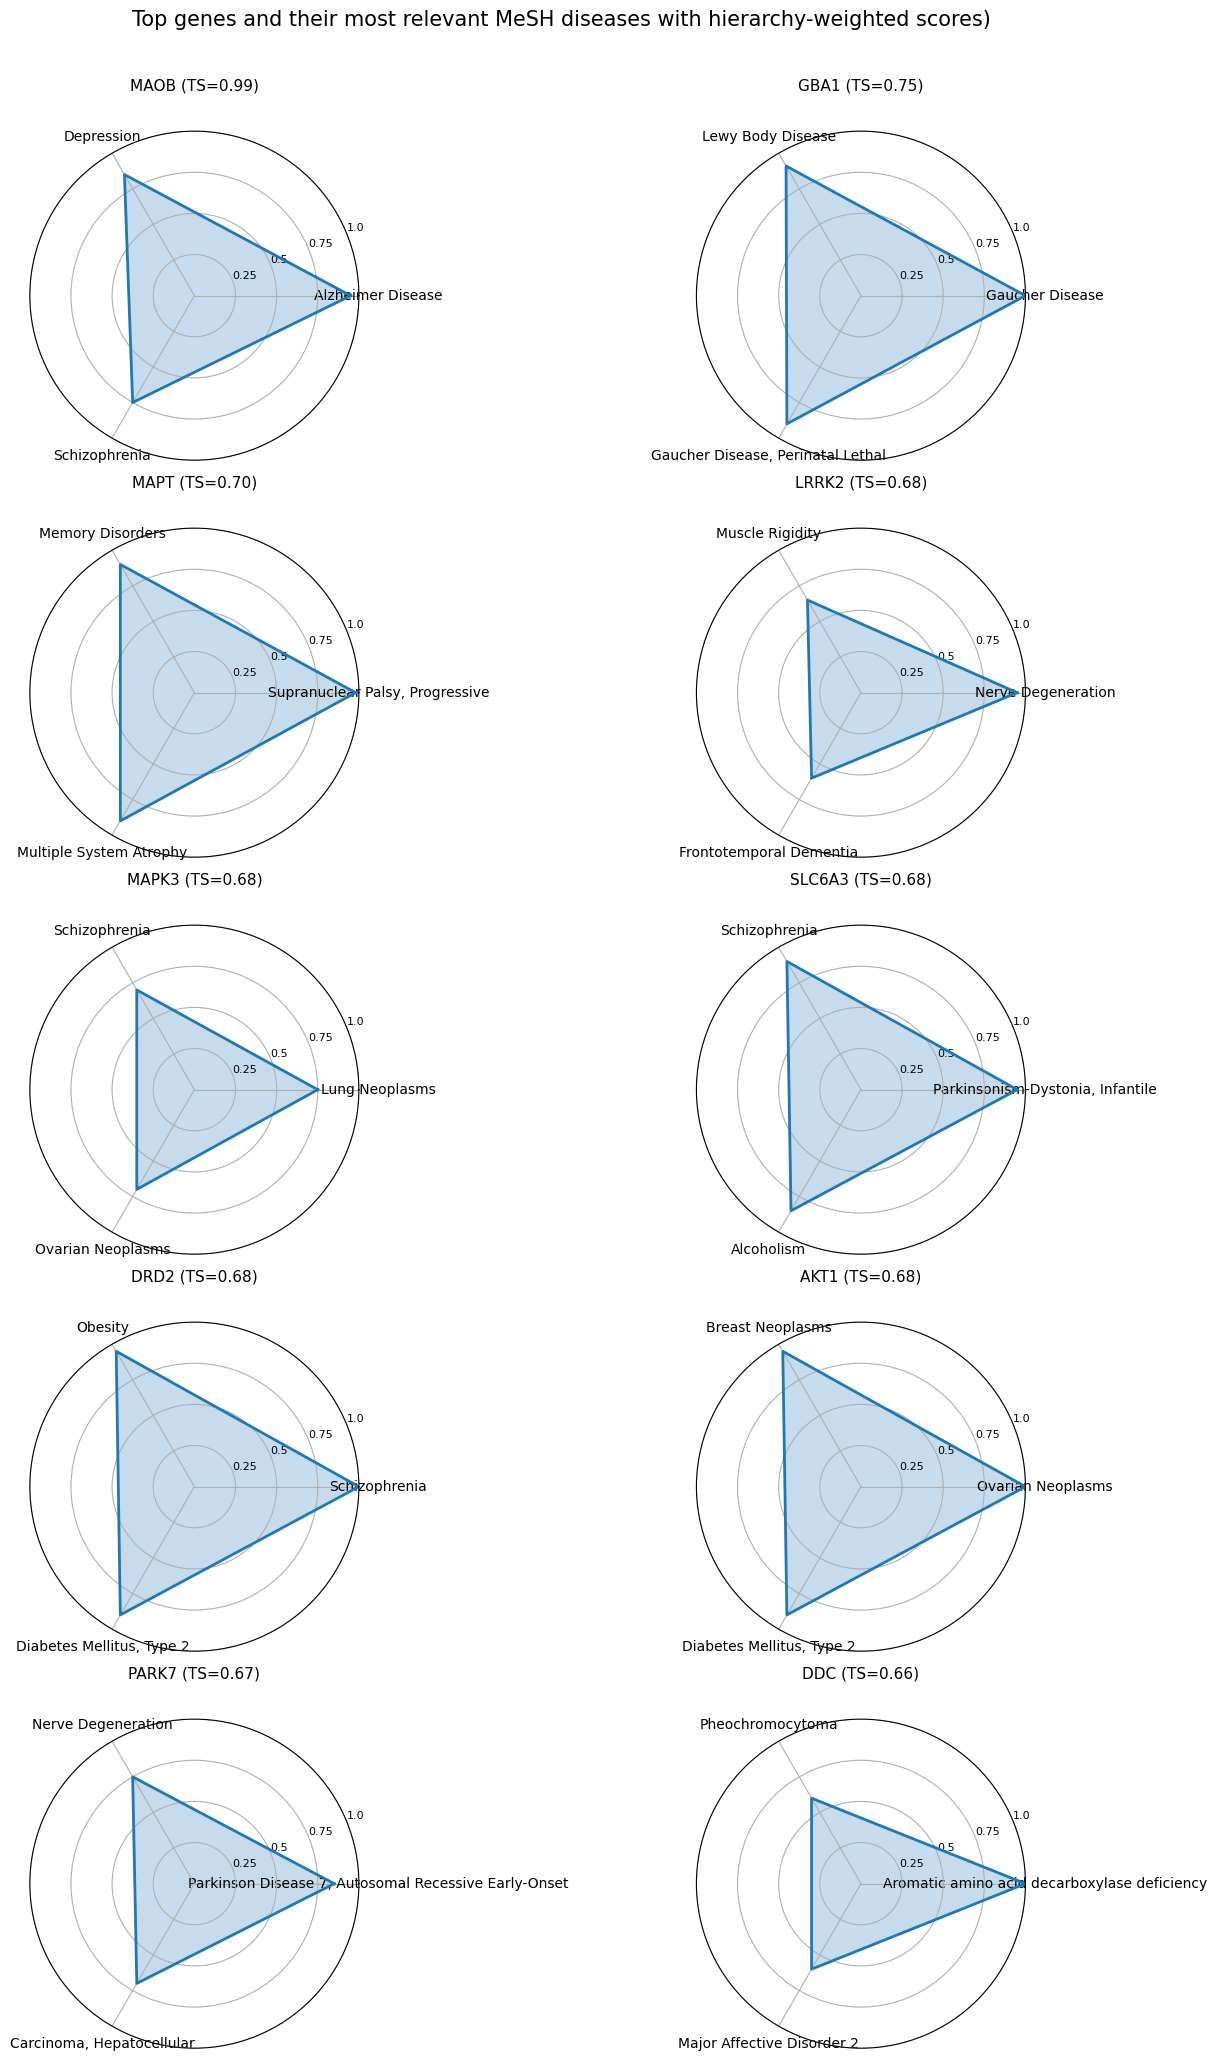

In [9]:
# Load data
df = merged_df

score_cols = ["Top_Disease_1_Score", "Top_Disease_2_Score", "Top_Disease_3_Score"]
df[score_cols] = df[score_cols].astype(float)

categories = ["Disease 1", "Disease 2", "Disease 3"]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

top_genes = df.sort_values("TS", ascending=False).head(10)

fig, axes = plt.subplots(5, 2, figsize=(14, 20), subplot_kw={'polar': True})
axes = axes.flatten()
for i, (_, row) in enumerate(top_genes.iterrows()):
    values = [row["Top_Disease_1_Score"], row["Top_Disease_2_Score"], row["Top_Disease_3_Score"]]
    values += values[:1]
    disease_labels = [row["Top_Disease_1_Name"], row["Top_Disease_2_Name"], row["Top_Disease_3_Name"]]
    ax = axes[i]
    ax.plot(angles, values, linewidth=2, linestyle='solid')
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(disease_labels, fontsize=10)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f"{row['Gene']} (TS={row['TS']:.2f})", size=11, y=1.1)
plt.tight_layout()
plt.suptitle("Top genes and their most relevant MeSH diseases with hierarchy-weighted scores)", fontsize=15, y=1.03)
plt.show()

In [11]:
%%skip

### Untested

# Extract unique MeSH IDs across top 3 diseases
mesh_cols = ["Top_Disease_1_ID", "Top_Disease_2_ID", "Top_Disease_3_ID"]
mesh_ids = pd.unique(merged_df[mesh_cols].values.ravel())
mesh_ids = [mid for mid in mesh_ids if pd.notna(mid)]

# Construct POST request payload for CTD
ctd_url = "https://ctdbase.org/tools/batchQuery.go"
payload = {
    "inputType": "disease",
    "inputTerms": "\n".join(mesh_ids),
    "report": "chems_curated",
    "format": "tsv"
}

# Send POST request
response = requests.post(ctd_url, data=payload)

# Save and process response
if response.status_code == 200:
    output_file = "../data/ctd_disease_drug_results.tsv"
    with open(output_file, "w") as f:
        f.write(response.text)

    df = pd.read_csv(output_file, sep="\t")
    print(f"Raw entries: {len(df)}")

    # Filter only therapeutic drugs
    df = df[df["DirectEvidence"].str.contains("therapeutic", na=False)].copy()
    df["DiseaseID"] = df["DiseaseID"].str.replace("MESH:", "")

    # Save clean version
    clean_output = "../data/ctd_disease_drug_filtered.csv"
    df.to_csv(clean_output, index=False)
    print(f"Filtered therapeutic drugs: {len(df)}")
    print(f"Saved to: {clean_output}")
else:
    print("Request failed:", response.status_code)

Skipped cell
